# Figure 1(b): position bias and human misalignment

Reads the saved summaries written by

```bash
python run_real_data.py --study motivation --dataset all
```

and renders the two-panel motivation figure into this repo's `figures/`
directory. No analysis happens here, so the visualization can be restyled
without re-running anything.

**Panel (a)** is the share of records whose verdict *changes* when the two
responses are swapped, among records the judge decides in both orders. This
measures order-dependence irrespective of its direction: a judge that favours the
second position is just as order-dependent as one favouring the first, and a
judge with no net directional preference can still flip on most records. The
directional quantity, `first_position_rate`, is saved and reported below but is
not the panel, because a value near `0.5` there can mean either no order effect
or two offsetting ones.

**Panel (b)** is disagreement with the human label, restricted to records where the
judge returns the *same* verdict in both orders. On that subset the verdict is
invariant to display order, so the residual gap is not attributable to position
bias. Note that this conditions on each judge's own order-stable comparisons — a
subset favourable to the judge — so the plotted disagreement is a lower bound.

Layout is two stacked strips at roughly 2:1, judges on a shared x axis sorted by
panel (a) descending. Both panels have `0` as the ideal, so panel (a) falls
monotonically by construction while panel (b) stays flat — that contrast is the
point of the figure.

Metric definitions and the exclusion rules are documented in
`experiments/README.md`.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Everything stays inside the DIAL repo so it remains self-contained. The
# rendered PDFs are copied into the paper's figures/ directory separately.
REPO = Path.cwd().parent
RESULTS = REPO / "results" / "motivation"
FIGURES = REPO / "figures"


DATASETS = ["arena_33k", "mt_bench", "pandalm"]
DATASET_LABELS = {
    "arena_33k": "Chatbot Arena",
    "mt_bench": "MT-Bench",
    "pandalm": "PandaLM",
}

# Categorical slots 1-3 of the validated reference palette. Marker shape is a
# second, redundant encoding of study identity, so the figure survives
# colour-vision deficiency and grayscale printing.
DATASET_COLORS = {"arena_33k": "#2a78d6", "mt_bench": "#eb6834", "pandalm": "#1baf7a"}
DATASET_MARKERS = {"arena_33k": "o", "mt_bench": "s", "pandalm": "^"}

INK = "#0b0b0b"
INK_SOFT = "#52514e"
GRID = "#e4e3df"

mpl.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Nimbus Roman", "DejaVu Serif"],
        "font.size": 8,
        "axes.labelsize": 8.5,
        "axes.titlesize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 7.5,
        "legend.fontsize": 8,
        "axes.edgecolor": INK_SOFT,
        "axes.linewidth": 0.6,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.dpi": 300,
        "figure.dpi": 150,
    }
)

In [2]:
def latest_run(dataset):
    """Most recent result directory for one dataset."""
    runs = sorted(RESULTS.glob(f"{dataset}-*"))
    if not runs:
        raise FileNotFoundError(
            f"no motivation results for {dataset}; run "
            f"`python run_real_data.py --study motivation --dataset {dataset}` first"
        )
    return runs[-1]


runs = {d: latest_run(d) for d in DATASETS}
summary = pd.concat([pd.read_csv(p / "per_judge.csv") for p in runs.values()], ignore_index=True)

for dataset, path in runs.items():
    print(f"{dataset:<10} {path.name}")
print()
print(summary.groupby("dataset").agg(judges=("judge", "size"), excluded=("excluded_from_figure", "sum")))

arena_33k  arena_33k-20260906T090653Z
mt_bench   mt_bench-20260906T090653Z
pandalm    pandalm-20260906T090653Z

           judges  excluded
dataset                    
arena_33k      22         1
mt_bench       22         1
pandalm        22         1


In [3]:
def _stem(judge):
    name = judge
    for prefix in ("ollama-", "openai-", "anthropic-", "google-"):
        name = name.removeprefix(prefix)
    for suffix in ("-batch-direct", "-batch-minimal", "-direct", "-low", "-thinking"):
        name = name.removesuffix(suffix)
    return name


def build_labels(frame):
    """Compact axis labels, disambiguated only where two aliases collide.

    Two judges in the panel share weights and differ only in whether reasoning
    is enabled (qwen3-30b-a3b and glm-4.7-flash). Those rows are qualified
    `(direct)` / `(thinking)`, taken from the recorded inference config rather
    than parsed from the alias suffix.

    `low` and `minimal` are per-provider effort settings *within* the thinking
    state, on no common cross-provider scale, so they are not levels in the
    figure. The table in the next cell documents which model used which, for
    the paper to state.
    """
    modes = frame.drop_duplicates("judge").set_index("judge")["reasoning"].to_dict()
    stems = {judge: _stem(judge) for judge in modes}
    counts = pd.Series(list(stems.values())).value_counts()
    return {
        judge: stem if counts[stem] == 1 else f"{stem} ({modes[judge]})"
        for judge, stem in stems.items()
    }


plotted = summary[~summary["excluded_from_figure"]].copy()

# Panel (b) is plotted as a deviation from the human label, so that both panels
# share 0 as the ideal and read "further right = worse".
plotted["disagreement"] = 1 - plotted["agreement_consistent"]
plotted["disagreement_lo"] = 1 - plotted["agreement_consistent_hi"]
plotted["disagreement_hi"] = 1 - plotted["agreement_consistent_lo"]

# Built from every judge, so excluded ones still have a name in the tables.
LABELS = build_labels(summary)
plotted["label"] = plotted["judge"].map(LABELS)

# One ordering, held across both panels: sorting by position bias in panel (a)
# and seeing that order carry no information in panel (b) is the visual form of
# the claim that the two are distinct phenomena.
# Descending, so the most order-dependent judges lead on the left.
order = (
    plotted.groupby("judge")["swap_inconsistency_rate"].mean().sort_values(ascending=False)
)
judge_order = list(order.index)
positions = {judge: i for i, judge in enumerate(judge_order)}

excluded = summary[summary["excluded_from_figure"]][
    ["dataset", "judge", "judge_tie_rate", "coverage", "high_tie_rate", "low_coverage"]
]
print("excluded from the figure:")
print(excluded.to_string(index=False))

excluded from the figure:
  dataset                       judge  judge_tie_rate  coverage  high_tie_rate  low_coverage
arena_33k ollama-stablelm2-12b-direct        0.677075  0.995477           True         False
 mt_bench ollama-stablelm2-12b-direct        0.655923  0.993328           True         False
  pandalm ollama-stablelm2-12b-direct        0.738486  0.998942           True         False


### Judge reasoning configuration

The figure distinguishes only **direct** (reasoning disabled) from **thinking**
(reasoning enabled or required). Within *thinking*, the effort level is a
per-provider setting — `low` for the Ollama models, `minimal` for Gemini, unset
for GLM — and those are not comparable across providers, so they are not levels
in the plot. The table below is the source for that clarification in the paper.

Note the confound worth stating alongside it: the direct configuration also caps
`max_output_tokens` at 16, against 4096 under thinking. "Direct vs thinking" is
therefore a difference in decoding configuration, not in reasoning alone.

In [4]:
config = (
    summary.drop_duplicates("judge")[
        ["judge", "judge_model", "reasoning", "reasoning_effort"]
    ]
    .assign(figure_label=lambda d: d["judge"].map(LABELS))
    .sort_values(["reasoning", "judge"])
    .reset_index(drop=True)
)
config["reasoning_effort"] = config["reasoning_effort"].fillna("—")
print(config.to_string(index=False))

print()
print(config.groupby(["reasoning", "reasoning_effort"])["judge"].size().to_string())

# The same-weights reasoning toggles: the panel's one controlled contrast.
toggles = (
    plotted[plotted["judge_model"].isin(
        plotted.groupby("judge_model")["reasoning"].nunique().pipe(lambda s: s[s > 1]).index
    )]
    .pivot_table(
        index=["judge_model", "dataset"],
        columns="reasoning",
        values=["swap_inconsistency_rate", "agreement_consistent"],
    )
    .round(3)
)
print()
print("same-weights reasoning toggles (direct vs thinking):")
print(toggles.to_string())

                                     judge               judge_model reasoning reasoning_effort             figure_label
   anthropic-claude-haiku-4.5-batch-direct claude-haiku-4-5-20251001    direct                —         claude-haiku-4.5
                 ollama-gemma-3-27b-direct                gemma3:27b    direct                —              gemma-3-27b
                ollama-gemma-3n-e4b-direct               gemma3n:e4b    direct                —             gemma-3n-e4b
               ollama-glm-4.7-flash-direct      glm-4.7-flash:q4_K_M    direct                —   glm-4.7-flash (direct)
                     ollama-glm4-9b-direct                   glm4:9b    direct                —                  glm4-9b
               ollama-llama-3.3-70b-direct              llama3.3:70b    direct                —            llama-3.3-70b
       ollama-mistral-small-3.2-24b-direct      mistral-small3.2:24b    direct                —    mistral-small-3.2-24b
                    ollama-phi4-

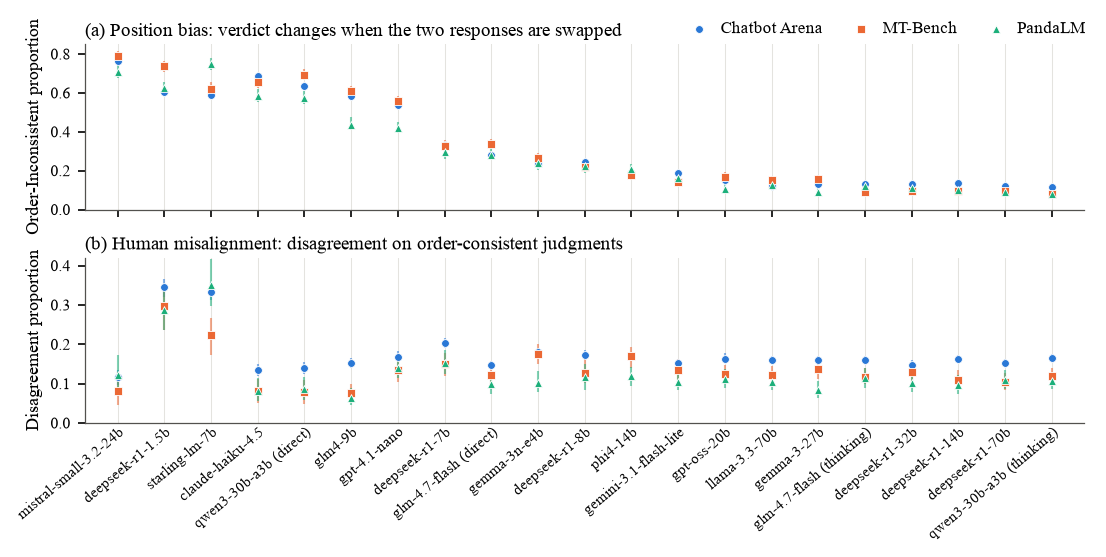

In [5]:
def panel(ax, metric, tag, ylabel, ylim):
    """One metric strip: judges along x, one marker per study."""
    for x in positions.values():
        ax.axvline(x, color=GRID, lw=0.5, zorder=0)

    for dataset in DATASETS:
        rows = plotted[(plotted["dataset"] == dataset) & plotted["judge"].isin(positions)]
        x = rows["judge"].map(positions).to_numpy(dtype=float)
        ax.vlines(
            x,
            rows[f"{metric}_lo"].to_numpy(dtype=float),
            rows[f"{metric}_hi"].to_numpy(dtype=float),
            color=DATASET_COLORS[dataset],
            lw=1.0,
            alpha=0.55,
            zorder=2,
        )
        ax.scatter(
            x,
            rows[metric].to_numpy(dtype=float),
            s=14,
            marker=DATASET_MARKERS[dataset],
            facecolor=DATASET_COLORS[dataset],
            edgecolor="white",
            linewidth=0.4,
            zorder=3,
            label=DATASET_LABELS[dataset],
        )

    ax.set_xlim(-0.7, len(judge_order) - 0.3)
    ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel)
    ax.set_title(tag, loc="left", pad=4)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)


# Stacked strips at 2:1, sharing the judge axis. 0 is the ideal in both panels.
fig, axes = plt.subplots(2, 1, figsize=(7.4, 3.7), sharex=True)

panel(
    axes[0],
    "swap_inconsistency_rate",
    "(a) Position bias: verdict changes when the two responses are swapped",
    "Order-Inconsistent proportion",
    (0, 0.85),
)
panel(
    axes[1],
    "disagreement",
    "(b) Human misalignment: disagreement on order-consistent judgments",
    "Disagreement proportion",
    (0, 0.42),
)

axes[1].set_xticks(range(len(judge_order)))
axes[1].set_xticklabels(
    [LABELS[j] for j in judge_order],
    rotation=40,
    ha="right",
    rotation_mode="anchor",
    color=INK,
    fontsize=7,
)
axes[1].tick_params(axis="x", length=0, pad=1)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.998, .998),
    handletextpad=0.3,
    columnspacing=1.3,
)
fig.tight_layout()

FIGURES.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES / "fig1b_position_vs_alignment.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Numbers for the caption

Ranges, denominators, and exclusions, so the caption states what the panels
actually show rather than an approximation of it.

In [6]:
for dataset in DATASETS:
    rows = plotted[plotted["dataset"] == dataset]
    print(f"{DATASET_LABELS[dataset]}  ({len(rows)} judges shown)")
    print(
        f"  swap inconsistency  [panel a]   {rows['swap_inconsistency_rate'].min():.3f} - "
        f"{rows['swap_inconsistency_rate'].max():.3f}"
    )
    print(
        f"  agreement, consistent [panel b] {rows['agreement_consistent'].min():.3f} - "
        f"{rows['agreement_consistent'].max():.3f}"
    )
    print(
        f"  first-position rate (direction) {rows['first_position_rate'].min():.3f} - "
        f"{rows['first_position_rate'].max():.3f}"
    )
    print(
        f"  judge tie rate                  {rows['judge_tie_rate'].min():.3f} - "
        f"{rows['judge_tie_rate'].max():.3f}"
    )
    print(f"  human non-decisive              {rows['human_nondecisive_rate'].mean():.3f}")
    print(
        f"  median n (panel a / panel b)    {rows['n_swap_inconsistency_rate'].median():.0f}"
        f" / {rows['n_agreement_consistent'].median():.0f}"
    )
    print()

# Are the two panels measuring the same thing? They should not be.
corr = plotted.groupby("dataset").apply(
    lambda d: d["swap_inconsistency_rate"].corr(d["disagreement"]),
    include_groups=False,
)
print("corr(swap_inconsistency_rate, 1 - agreement_consistent):")
print(corr.round(3).to_string())

# How many judges favour the second position? A directional summary alone would
# report these as biased in the opposite direction, and a judge whose two
# offsetting effects cancel would look unbiased.
second = plotted[plotted["first_position_rate"] < 0.5]
print()
print(f"judge-study cells favouring the SECOND position: {len(second)} of {len(plotted)}")
print(
    second.groupby("dataset")
    .agg(n=("judge", "size"), lowest_first_position_rate=("first_position_rate", "min"))
    .to_string()
)

Chatbot Arena  (21 judges shown)
  swap inconsistency  [panel a]   0.115 - 0.767
  agreement, consistent [panel b] 0.655 - 0.884
  first-position rate (direction) 0.115 - 0.788
  judge tie rate                  0.002 - 0.175
  human non-decisive              0.296
  median n (panel a / panel b)    6772 / 3996

MT-Bench  (21 judges shown)
  swap inconsistency  [panel a]   0.079 - 0.792
  agreement, consistent [panel b] 0.702 - 0.924
  first-position rate (direction) 0.111 - 0.850
  judge tie rate                  0.004 - 0.145
  human non-decisive              0.291
  median n (panel a / panel b)    1054 / 633

PandaLM  (21 judges shown)
  swap inconsistency  [panel a]   0.080 - 0.750
  agreement, consistent [panel b] 0.649 - 0.936
  first-position rate (direction) 0.142 - 0.791
  judge tie rate                  0.004 - 0.247
  human non-decisive              0.106
  median n (panel a / panel b)    763 / 536

corr(swap_inconsistency_rate, 1 - agreement_consistent):
dataset
arena_33k    

## Supplementary: the DeepSeek-R1 size ladder

Whether larger judges are both less position-biased and more human-aligned, using
the one judge family collected at several sizes. Kept out of Figure 1(b) so the
two panels stay legible.

`ollama-deepseek-r1-70b-low` is uncollected for Chatbot Arena and PandaLM (about
1.5% record coverage in each) and `-32b-` has no Arena responses at all, so those
points are absent rather than imputed.

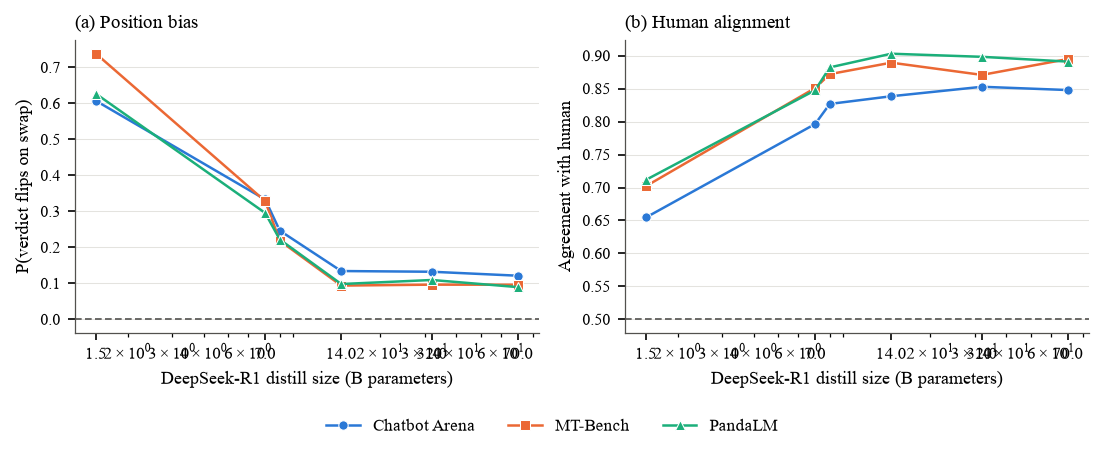

In [7]:
LADDER = [
    ("ollama-deepseek-r1-1.5b-low", 1.5),
    ("ollama-deepseek-r1-7b-low", 7),
    ("ollama-deepseek-r1-8b-low", 8),
    ("ollama-deepseek-r1-14b-low", 14),
    ("ollama-deepseek-r1-32b-low", 32),
    ("ollama-deepseek-r1-70b-low", 70),
]
sizes = pd.DataFrame(LADDER, columns=["judge", "params_b"])
ladder = plotted.merge(sizes, on="judge").sort_values("params_b")

fig, axes = plt.subplots(1, 2, figsize=(7.4, 2.9))
for ax, metric, ylabel, title, reference in (
    (axes[0], "swap_inconsistency_rate", "P(verdict flips on swap)", "(a) Position bias", 0.0),
    (axes[1], "agreement_consistent", "Agreement with human", "(b) Human alignment", 0.5),
):
    ax.axhline(reference, color=INK_SOFT, lw=0.8, ls=(0, (4, 2)), zorder=1)
    for dataset in DATASETS:
        rows = ladder[ladder["dataset"] == dataset]
        if rows.empty:
            continue
        ax.plot(
            rows["params_b"],
            rows[metric],
            marker=DATASET_MARKERS[dataset],
            color=DATASET_COLORS[dataset],
            lw=1.2,
            ms=4.5,
            markeredgecolor="white",
            markeredgewidth=0.5,
            label=DATASET_LABELS[dataset],
        )
    ax.set_xscale("log")
    ax.set_xticks([1.5, 7, 14, 32, 70])
    ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
    ax.set_xlabel("DeepSeek-R1 distill size (B parameters)")
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc="left", pad=6)
    ax.grid(axis="y", color=GRID, lw=0.5)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig(FIGURES / "fig_deepseek_ladder.pdf", dpi=300, bbox_inches="tight")
plt.show()